In [3]:
!pip install mlxtend
!pip install onnxmltools
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.5/352.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 121.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.9 MB/s eta 0:00:00


In [4]:
!pip install skl2onnx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 24.7 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from mlxtend.plotting import heatmap
import xgboost as xgb
import onnxruntime as rt
import onnxmltools
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType




In [6]:
batch_size    = 16
learning_rate = 0.005
N_Epochs      = 100
epsilon       = 1e-4
random_seed   = 42
np.random.seed(random_seed); random.seed(random_seed); torch.manual_seed(random_seed)


In [7]:
path_data = '/content/drive/MyDrive/waterQuality1.csv'

WATER_raw_data = pd.read_csv(path_data, delimiter=",")
WATER_raw_data



,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7994,0.05,7.78,0.00,1.95,0.040,0.10,0.03,0.03,1.37,0.00,...,0.197,14.29,1.00,0.005,3.57,2.13,0.09,0.06,0.03,1
7995,0.05,24.22,0.02,0.59,0.010,0.45,0.02,0.02,1.48,0.00,...,0.031,10.27,1.00,0.001,1.48,1.11,0.09,0.10,0.08,1
7996,0.09,6.85,0.00,0.61,0.030,0.05,0.05,0.02,0.91,0.00,...,0.182,15.92,1.00,0.000,1.35,4.84,0.00,0.04,0.05,1
7997,0.01,10,0.01,2.00,0.000,2.00,0.00,0.09,0.00,0.00,...,0.000,0.00,0.00,0.000,0.00,0.00,0.00,0.00,0.00,1


In [8]:
headers_list = WATER_raw_data.columns.values.tolist()
headers_list


['aluminium',
 'ammonia',
 'arsenic',
 'barium',
 'cadmium',
 'chloramine',
 'chromium',
 'copper',
 'flouride',
 'bacteria',
 'viruses',
 'lead',
 'nitrates',
 'nitrites',
 'mercury',
 'perchlorate',
 'radium',
 'selenium',
 'silver',
 'uranium',
 'is_safe']

In [15]:
import pandas as pd, numpy as np

# 1) load your CSV
path_data = '/content/drive/MyDrive/waterQuality1.csv'   # <-- change if needed
WATER_raw_data = pd.read_csv(path_data)

# 2) convert everything that looks like a number to numeric; coerce junk to NaN
bad_tokens = ['#NUM!', '#DIV/0!', 'N/A', 'NA', 'null', 'Null', 'NULL', 'nan', 'NaN', '']
WATER_num = (
    WATER_raw_data
      .replace(bad_tokens, np.nan)
      .apply(pd.to_numeric, errors='coerce')
)

# (optional) drop the label column from the correlation, if the last column is your label
target = WATER_raw_data.columns[-1]        # last col is label in your notebook
if target in WATER_num.columns:
    WATER_num = WATER_num.drop(columns=[target])

WATER_num = WATER_num.fillna(WATER_num.mean(numeric_only=True))


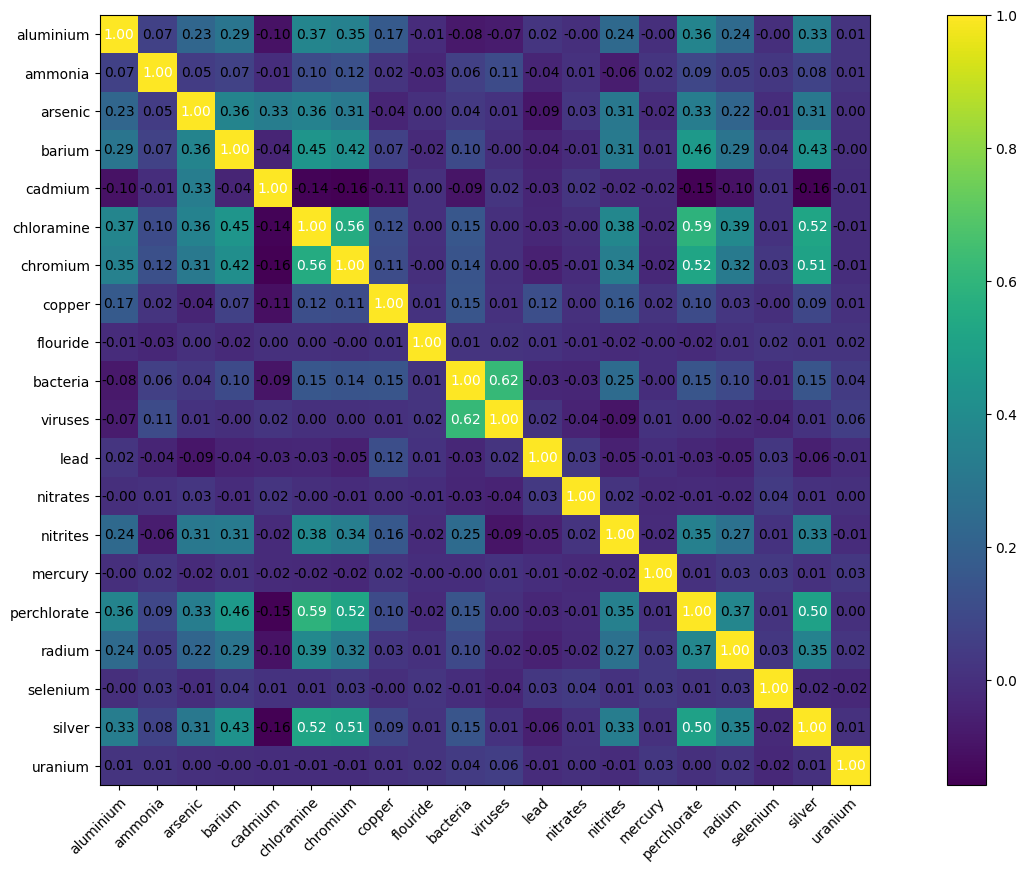

In [16]:
headers_list = WATER_num.columns.tolist()
cm = np.corrcoef(WATER_num[headers_list].values.T)
hm = heatmap(cm, row_names=headers_list, column_names=headers_list, figsize=(20,10))
plt.show()


In [17]:
WATER_raw_data_np = WATER_num.to_numpy()
X = WATER_raw_data_np[:, :-1].astype(np.float32)
y = WATER_raw_data_np[:, -1:].astype(np.float32)
X.shape, y.shape


((7999, 19), (7999, 1))

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)
X_train_tr = torch.from_numpy(X_train)
X_test_tr  = torch.from_numpy(X_test)
y_train_tr = torch.from_numpy(y_train)
y_test_tr  = torch.from_numpy(y_test)

x_means      = X_train_tr.mean(0, keepdim=True)
x_deviations = X_train_tr.std(0, keepdim=True) + epsilon

train_ds = TensorDataset(X_train_tr, y_train_tr)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)


In [19]:
import torch.nn as nn
import torch.nn.functional as F

class LinRegNet(nn.Module):
    def __init__(self, x_means, x_deviations):
        super().__init__()
        self.x_means = x_means
        self.x_deviations = x_deviations
        self.linear1 = nn.Linear(20, 1)
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        return self.linear1(x)

class MLP_Net(nn.Module):
    def __init__(self, x_means, x_deviations):
        super().__init__()
        self.x_means = x_means
        self.x_deviations = x_deviations
        self.linear1 = nn.Linear(20, 8)
        self.act1 = nn.Sigmoid()
        self.dropout = nn.Dropout(0.25)
        self.linear2 = nn.Linear(8, 1)
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x); x = self.act1(x); x = self.dropout(x)
        return self.linear2(x)

class DL_Net(nn.Module):
    def __init__(self, x_means, x_deviations):
        super().__init__()
        self.x_means = x_means
        self.x_deviations = x_deviations
        self.linear1 = nn.Linear(20, 10)
        self.act1 = nn.ReLU()
        self.linear2 = nn.Linear(10, 6)
        self.act2 = nn.ReLU()
        self.linear3 = nn.Linear(6, 1)
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x); x = self.act1(x)
        x = self.linear2(x); x = self.act2(x)
        return self.linear3(x)

class LinearPlusNonlinear_Net(nn.Module):
    def __init__(self, x_means, x_deviations):
        super().__init__()
        self.x_means = x_means
        self.x_deviations = x_deviations
        self.f1_linear  = nn.Linear(20, 1)
        self.f2_linear1 = nn.Linear(20, 6)
        self.f2_act1    = nn.ReLU()
        self.f2_linear2 = nn.Linear(6, 1)
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        f1 = self.f1_linear(x)
        f2 = self.f2_linear2(self.f2_act1(self.f2_linear1(x)))
        return f1 + f2


In [20]:
def training_loop(N_Epochs, model, loss_fn, opt):
    for epoch in range(N_Epochs):
        for xb, yb in train_dl:
            y_pred = model(xb)
            loss   = loss_fn(y_pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        if epoch % 20 == 0:
            print(epoch, "loss=", float(loss.detach().cpu()))


In [23]:
# 1) confirm feature count
print("X_train shape:", X_train.shape)   # (N, d)
d = X_train.shape[1]

# 2) recompute scaling from train
x_means = torch.tensor(X_train.mean(0), dtype=torch.float32)
x_deviations = torch.tensor(X_train.std(0) + 1e-8, dtype=torch.float32)

# 3) define a model that takes d features
import torch.nn as nn

class DL_Net(nn.Module):
    def __init__(self, in_dim, xm, xd):
        super().__init__()
        self.xm, self.xd = xm, xd
        self.fc1 = nn.Linear(in_dim, 10)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)   # regression
    def forward(self, x):
        x = (x - self.xm) / self.xd
        x = self.act1(self.fc1(x))
        return self.fc2(x)

model = DL_Net(d, x_means, x_deviations)


X_train shape: (6399, 19)


In [27]:
model = DL_Net(x_means, x_deviations)
opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = F.mse_loss
training_loop(N_Epochs, model, loss_fn, opt)
with torch.no_grad():
    y_pred_test = model(X_test_tr).cpu().numpy()
print("Testing R**2: ", r2_score(y_test_tr.numpy(), y_pred_test))


TypeError: DL_Net.__init__() missing 1 required positional argument: 'xd'

In [28]:
y_pred_test = model( X_test_tr )

In [137]:
y_pred_test.shape

torch.Size([1600, 1])

In [138]:
y_test_tr.shape

torch.Size([1600, 1])

In [139]:
len(X_test_tr)

1600

In [140]:
list_preds = []
list_reals = []

for i in range(len(X_test_tr)):
    print("************************************")
    print("pred, real")
    np_real =   y_test_tr[i].detach().numpy()
    np_pred = y_pred_test[i].detach().numpy()
    print(( np_pred  , np_real))
    list_preds.append(np_pred[0])
    list_reals.append(np_real[0])

************************************
pred, real
(array([0.39105216], dtype=float32), array([0.], dtype=float32))
************************************
pred, real
(array([0.31958538], dtype=float32), array([0.], dtype=float32))
************************************
pred, real
(array([0.01651619], dtype=float32), array([0.], dtype=float32))
************************************
pred, real
(array([0.00563427], dtype=float32), array([0.], dtype=float32))
************************************
pred, real
(array([-0.00566696], dtype=float32), array([0.], dtype=float32))
************************************
pred, real
(array([-0.00823693], dtype=float32), array([0.], dtype=float32))
************************************
pred, real
(array([0.01215774], dtype=float32), array([0.], dtype=float32))
************************************
pred, real
(array([0.31665614], dtype=float32), array([0.], dtype=float32))
************************************
pred, real
(array([0.05136117], dtype=float32), array([0.

In [141]:
regressor = xgb.XGBRegressor(

        n_estimators=100,
        reg_lambda=1,
        gamma=0,
        max_depth=3
)

In [142]:
regressor.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [143]:
y_pred = regressor.predict(X_test)

In [144]:
y_pred.shape

(1600,)

In [145]:
y_pred

array([ 0.12085492,  0.27981132, -0.03655218, ..., -0.00153721,
       -0.01547985, -0.04930299], dtype=float32)

In [146]:
r2_score(y_test, y_pred)

0.6657129526138306

In [147]:
initial_types = [(
          'float_input',
          FloatTensorType(  [None, 18 ]  )

)]

In [148]:
onnx_model = onnxmltools.convert_xgboost(regressor, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, 'xgboost_WaterQuality_ort.onnx')

ValueError: could not convert string to float: '[1.1132086E-1]'

In [149]:
model = MLP_Net(x_means, x_deviations)   # input dim = 20 in your class above
opt     = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = F.mse_loss

def training_loop(N_Epochs, model, loss_fn, opt):
    for epoch in range(100):
        for xb, yb in train_dl:
            y_pred = model(xb)
            loss   = loss_fn(y_pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if epoch % 20 == 0:
            print(epoch, "loss=", float(loss.detach()))

training_loop(100, model, loss_fn, opt)

with torch.no_grad():
    y_pred_test = model(X_test_tr).cpu().numpy()
print("Testing R**2:", r2_score(y_test_tr.numpy(), y_pred_test))


0 loss= 0.09218215942382812
20 loss= 0.06424828618764877
40 loss= 0.10775390267372131
60 loss= 0.055163197219371796
80 loss= 0.059136804193258286
Testing R**2: 0.3946809768676758


In [1]:
model.eval()
dummy = torch.randn(1, 20)  # 20 features
torch.onnx.export(
    model,
    dummy,
    "MLP_WaterQuality20.onnx",
    verbose=False,
    input_names=["input1"],
    output_names=["output1"]
)
print("Saved:", "MLP_WaterQuality20.onnx")


NameError: name 'model' is not defined